# Disease Symptom Prediction - Model Development & Evaluation

## Project

AI Disease Prediction System

## Objectiv# Disease Symptom Prediction - Model Training & Rigorous Evaluation

## Project

AI Disease Prediction System

## Objective

The objective of this notebook is to develop, train, compare, and rigorously evaluate multiple machine learning models for multi-class disease prediction.

The processed dataset generated during the data-cleaning stage will be used as the input.

The dataset contains repeated symptom patterns, so duplicate-aware evaluation will be used to reduce the risk of data leakage.

## Week 3 Workflow

The workflow includes:

- Loading and validating the processed dataset
- Separating features and target
- Identifying categorical and numerical features
- Creating duplicate-aware symptom-pattern groups
- Creating a group-aware train/test split
- Building preprocessing pipelines
- Establishing a baseline model
- Handling class imbalance using SMOTE inside the training pipeline
- Training multiple classification models
- Performing Stratified Group K-Fold cross-validation
- Comparing model performance
- Evaluating the selected model on a held-out test set
- Generating a classification report
- Generating a confusion matrix
- Performing per-class performance analysis
- Saving the final machine learning pipeline
- Saving model evaluation results

## Evaluation Strategy

Because the dataset contains multiple disease classes and repeated symptom patterns, model evaluation will focus on:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- ROC-AUC where applicable

Macro F1-score will be used as the primary model-comparison metric because it gives equal importance to each disease class.

The objective of this notebook is to develop, train, compare, and evaluate
multiple machine learning models for multi-class disease prediction.

The processed dataset generated during the data-cleaning stage will be used
as the input.

The workflow includes:

- Loading the processed dataset
- Separating features and target
- Inspecting feature representation
- Creating training and testing datasets
- Building preprocessing pipelines
- Establishing a baseline model
- Training multiple classification models
- Performing cross-validation
- Comparing model performance
- Evaluating the best-performing model
- Generating a confusion matrix
- Analyzing classification performance
- Saving the final machine learning pipeline

---

**Author:** Shahbaj Tanvir Shawon

**Course:** CSE Project

**Notebook:** 03_Model_Development.ipynb

# 1. Import Required Libraries

This section imports the libraries required for:

- Data manipulation
- Data visualization
- Feature preprocessing
- Class imbalance handling
- Machine learning model development
- Group-aware cross-validation
- Model evaluation
- Model persistence

The notebook uses `SMOTENC` because the symptom features are categorical.

In [2]:
# --------------------------------------------------
# Suppress Warnings
# --------------------------------------------------

import warnings

warnings.filterwarnings("ignore")


# --------------------------------------------------
# File and Path Handling
# --------------------------------------------------

from pathlib import Path


# --------------------------------------------------
# Data Manipulation
# --------------------------------------------------

import numpy as np
import pandas as pd


# --------------------------------------------------
# Visualization
# --------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------
# Imbalanced-Learn
# --------------------------------------------------

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline


# --------------------------------------------------
# Preprocessing
# --------------------------------------------------

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer


# --------------------------------------------------
# Model Selection and Cross-Validation
# --------------------------------------------------

from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_validate
)


# --------------------------------------------------
# Machine Learning Models
# --------------------------------------------------

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier


# --------------------------------------------------
# Evaluation Metrics
# --------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# --------------------------------------------------
# Model Persistence
# --------------------------------------------------

from joblib import dump


print("=" * 60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

LIBRARIES IMPORTED SUCCESSFULLY


# 2. Project Configuration

The processed dataset generated during the data-cleaning stage is used
as the input for model development.

Project paths are centralized in this section to make the notebook
maintainable and reduce path-related errors.

The trained machine learning pipeline will be saved in the project's
`models` directory.

In [3]:
# --------------------------------------------------
# Project Paths
# --------------------------------------------------

PROJECT_ROOT = Path("../")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

MODEL_DIR = PROJECT_ROOT / "models"


# --------------------------------------------------
# Create Required Directories
# --------------------------------------------------

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------
# Dataset Configuration
# --------------------------------------------------

DATA_FILE = PROCESSED_DATA_DIR / "disease_clean.csv"


# --------------------------------------------------
# Target Configuration
# --------------------------------------------------

TARGET_COLUMN = "Disease"


# --------------------------------------------------
# Display Configuration
# --------------------------------------------------

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print(f"Project root      : {PROJECT_ROOT.resolve()}")
print(f"Processed data    : {DATA_FILE.resolve()}")
print(f"Model directory   : {MODEL_DIR.resolve()}")
print(f"Target column     : {TARGET_COLUMN}")

print("\n✓ Project configuration completed successfully.")

PROJECT CONFIGURATION
Project root      : E:\AI_Disease_Prediction
Processed data    : E:\AI_Disease_Prediction\data\processed\disease_clean.csv
Model directory   : E:\AI_Disease_Prediction\models
Target column     : Disease

✓ Project configuration completed successfully.


# 3. Load Processed Dataset

The processed dataset generated by `01_Data_Cleaning.ipynb` is loaded
for model development.

The original processed dataset is not modified in this notebook.

The dataset will be used for feature preparation, model training,
cross-validation, and final evaluation.

In [4]:
# --------------------------------------------------
# Load Processed Dataset
# --------------------------------------------------

df = pd.read_csv(DATA_FILE)

print("=" * 60)
print("PROCESSED DATASET LOADED")
print("=" * 60)

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {df.shape[0]}")
print(f"Columns       : {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\n✓ Processed dataset loaded successfully.")

PROCESSED DATASET LOADED
Dataset shape : (4920, 19)
Rows          : 4920
Columns       : 19

Column names:
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']

First 5 rows:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,Symptom_Count
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3



✓ Processed dataset loaded successfully.


# 4. Initial Dataset Validation

Before model development, the processed dataset is validated to ensure
that the required structure is available.

The validation checks:

- Dataset is not empty
- Target column exists
- `Symptom_Count` exists
- Target contains no missing values
- Number of disease classes
- Duplicate records
- Missing values in the dataset

In [5]:
# --------------------------------------------------
# Dataset Validation
# --------------------------------------------------

assert not df.empty, "Dataset is empty."

assert TARGET_COLUMN in df.columns, \
    "Target column not found."

assert "Symptom_Count" in df.columns, \
    "Symptom_Count feature not found."

assert df[TARGET_COLUMN].isnull().sum() == 0, \
    "Target contains missing values."

assert df[TARGET_COLUMN].nunique() > 1, \
    "Dataset must contain more than one disease class."

print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

print(f"Rows             : {len(df)}")
print(f"Columns          : {len(df.columns)}")
print(f"Disease classes  : {df[TARGET_COLUMN].nunique()}")
print(f"Duplicate rows   : {df.duplicated().sum()}")
print(f"Missing values   : {df.isnull().sum().sum()}")

print("\n✓ Required dataset validation checks passed.")

DATASET VALIDATION
Rows             : 4920
Columns          : 19
Disease classes  : 41
Duplicate rows   : 4616
Missing values   : 46992

✓ Required dataset validation checks passed.


# 5. Separate Features and Target

The processed dataset is divided into input features and the target variable.

- `X` contains the symptom-related features used by the models.
- `y` contains the disease labels that the models will learn to predict.

The target column is removed from `X` to prevent target leakage.

In [6]:
# --------------------------------------------------
# Separate Features and Target
# --------------------------------------------------

X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

print("=" * 60)
print("FEATURES AND TARGET SEPARATED")
print("=" * 60)

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Number of features   : {X.shape[1]}")
print(f"Number of classes    : {y.nunique()}")

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts().head(10))

print("\n✓ Features and target separated successfully.")

FEATURES AND TARGET SEPARATED
Feature matrix shape : (4920, 18)
Target shape         : (4920,)
Number of features   : 18
Number of classes    : 41

Feature columns:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']

Target distribution:
Disease
Fungal infection       120
Allergy                120
GERD                   120
Chronic cholestasis    120
Drug Reaction          120
Peptic ulcer diseae    120
AIDS                   120
Diabetes               120
Gastroenteritis        120
Bronchial Asthma       120
Name: count, dtype: int64

✓ Features and target separated successfully.


# 6. Identify Feature Types

The feature columns are divided into categorical and numerical features.

The symptom columns contain categorical symptom values, while
`Symptom_Count` represents the numerical count of symptoms present
for each patient record.

This feature-type information will be used by the preprocessing
pipeline and `SMOTENC`.

In [7]:
# --------------------------------------------------
# Identify Feature Types
# --------------------------------------------------

categorical_features = [
    col for col in X.columns
    if col.startswith("Symptom_") and col != "Symptom_Count"
]

numerical_features = ["Symptom_Count"]

print("=" * 60)
print("FEATURE TYPES")
print("=" * 60)

print(f"Categorical features : {len(categorical_features)}")
print(f"Numerical features   : {len(numerical_features)}")

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

# Validation checks
assert len(categorical_features) == 17, \
    "Expected 17 categorical symptom features."

assert "Symptom_Count" in X.columns, \
    "Symptom_Count is missing from the feature matrix."

print("\n✓ Feature types identified successfully.")

FEATURE TYPES
Categorical features : 17
Numerical features   : 1

Categorical features:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Numerical features:
['Symptom_Count']

✓ Feature types identified successfully.


# 7. Create Symptom Pattern Groups

To reduce data leakage caused by identical symptom patterns appearing
in different dataset partitions, each unique combination of symptoms
is treated as a group.

The group identifier is created using `Symptom_1` through `Symptom_17`.

The target variable (`Disease`) is not used to create the groups.

These groups will later be used with `StratifiedGroupKFold` so that
the same complete symptom pattern is not distributed across different
training and validation/test partitions.

In [8]:
# --------------------------------------------------
# Create Symptom Pattern Groups
# --------------------------------------------------

group_columns = categorical_features

groups = (
    X[group_columns]
    .fillna("__MISSING__")
    .astype(str)
    .agg("|".join, axis=1)
)

print("=" * 60)
print("SYMPTOM PATTERN GROUPS")
print("=" * 60)

print(f"Total records          : {len(X)}")
print(f"Unique symptom groups  : {groups.nunique()}")
print(f"Repeated groups        : {len(groups) - groups.nunique()}")

print("\nExample group identifiers:")
print(groups.head())

# Validation
assert len(groups) == len(X), \
    "Number of groups must match number of records."

assert groups.notnull().all(), \
    "Group identifiers contain missing values."

print("\n✓ Symptom pattern groups created successfully.")

SYMPTOM PATTERN GROUPS
Total records          : 4920
Unique symptom groups  : 304
Repeated groups        : 4616

Example group identifiers:
0    itching|skin_rash|nodal_skin_eruptions|dischro...
1    skin_rash|nodal_skin_eruptions|dischromic _pat...
2    itching|nodal_skin_eruptions|dischromic _patch...
3    itching|skin_rash|dischromic _patches|__MISSIN...
4    itching|skin_rash|nodal_skin_eruptions|__MISSI...
dtype: object

✓ Symptom pattern groups created successfully.


# 8. Stratified Group-Aware Train/Test Split

A stratified group-aware split is used to create the training and
held-out test datasets.

`StratifiedGroupKFold` provides two important properties:

1. Stratification helps maintain the distribution of disease classes.
2. Grouping prevents identical symptom-pattern groups from appearing
   in both training and test sets.

The first fold is used as the held-out test partition.

The test set will not be used during model selection or cross-validation.
It will be evaluated only after the final model has been selected.

In [9]:
# --------------------------------------------------
# Stratified Group-Aware Train/Test Split
# --------------------------------------------------

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

train_indices, test_indices = folds[0]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

groups_train = groups.iloc[train_indices].copy()
groups_test = groups.iloc[test_indices].copy()

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Total records : {len(X)}")
print(f"Training set  : {len(X_train)}")
print(f"Test set      : {len(X_test)}")

print(f"\nTraining ratio : {len(X_train) / len(X):.2%}")
print(f"Test ratio     : {len(X_test) / len(X):.2%}")

print(f"\nTraining groups : {groups_train.nunique()}")
print(f"Test groups     : {groups_test.nunique()}")

print("\n✓ Stratified group-aware split completed successfully.")

TRAIN / TEST SPLIT
Total records : 4920
Training set  : 3924
Test set      : 996

Training ratio : 79.76%
Test ratio     : 20.24%

Training groups : 245
Test groups     : 59

✓ Stratified group-aware split completed successfully.


In [10]:
# --------------------------------------------------
# Verify Class Distribution
# --------------------------------------------------

train_distribution = y_train.value_counts(normalize=True)
test_distribution = y_test.value_counts(normalize=True)

distribution_check = pd.DataFrame({
    "Train": train_distribution,
    "Test": test_distribution
}).fillna(0)

print("=" * 60)
print("CLASS DISTRIBUTION CHECK")
print("=" * 60)

display(distribution_check)

print(f"\nTraining classes : {y_train.nunique()}")
print(f"Test classes     : {y_test.nunique()}")

CLASS DISTRIBUTION CHECK


,Train,Test
Disease,,
(vertigo) Paroymsal Positional Vertigo,0.027523,0.012048
AIDS,0.027523,0.012048
Acne,0.029052,0.006024
Alcoholic hepatitis,0.010703,0.078313
Allergy,0.027523,0.012048
Arthritis,0.029052,0.006024
Bronchial Asthma,0.027523,0.012048
Cervical spondylosis,0.029052,0.006024
Chicken pox,0.027523,0.012048



Training classes : 41
Test classes     : 41


In [11]:
# --------------------------------------------------
# Verify No Group Leakage
# --------------------------------------------------

overlapping_groups = set(groups_train) & set(groups_test)

print("=" * 60)
print("GROUP LEAKAGE CHECK")
print("=" * 60)

print(f"Overlapping groups : {len(overlapping_groups)}")

assert len(overlapping_groups) == 0, \
    "Group leakage detected between training and test sets."

print("\n✓ No symptom-pattern groups overlap between training and test.")

GROUP LEAKAGE CHECK
Overlapping groups : 0

✓ No symptom-pattern groups overlap between training and test.


# 9. Prepare Data for SMOTENC

`SMOTENC` is used because the symptom features are categorical.

Before applying `SMOTENC`, the categorical features are converted to
string values and missing categorical values are represented using a
dedicated placeholder.

`Symptom_Count` is converted to a numeric type.

At this stage, no oversampling is performed for model training.
The actual SMOTENC operation will be placed inside the machine
learning pipeline so that oversampling occurs only on the training
portion of each cross-validation fold.

In [12]:
# --------------------------------------------------
# Prepare Features for SMOTENC
# --------------------------------------------------

X_train_smote = X_train.copy()
X_test_smote = X_test.copy()

# Prepare categorical features
for column in categorical_features:
    X_train_smote[column] = (
        X_train_smote[column]
        .fillna("__MISSING__")
        .astype(str)
    )

    X_test_smote[column] = (
        X_test_smote[column]
        .fillna("__MISSING__")
        .astype(str)
    )

# Prepare numerical feature
X_train_smote["Symptom_Count"] = pd.to_numeric(
    X_train_smote["Symptom_Count"],
    errors="coerce"
)

X_test_smote["Symptom_Count"] = pd.to_numeric(
    X_test_smote["Symptom_Count"],
    errors="coerce"
)

print("=" * 60)
print("SMOTENC DATA PREPARATION")
print("=" * 60)

print(f"Training feature shape : {X_train_smote.shape}")
print(f"Test feature shape     : {X_test_smote.shape}")

print("\nCategorical data types:")
print(X_train_smote[categorical_features].dtypes.value_counts())

print("\nNumerical data type:")
print(X_train_smote["Symptom_Count"].dtype)

print("\nMissing values:")
print(f"Training : {X_train_smote.isnull().sum().sum()}")
print(f"Test     : {X_test_smote.isnull().sum().sum()}")

print("\n✓ Data prepared for SMOTENC successfully.")

SMOTENC DATA PREPARATION
Training feature shape : (3924, 18)
Test feature shape     : (996, 18)

Categorical data types:
object    17
Name: count, dtype: int64

Numerical data type:
int64

Missing values:
Training : 0
Test     : 0

✓ Data prepared for SMOTENC successfully.


In [13]:
# --------------------------------------------------
# Identify Categorical Feature Indices
# --------------------------------------------------

categorical_indices = [
    X_train_smote.columns.get_loc(column)
    for column in categorical_features
]

print("=" * 60)
print("SMOTENC FEATURE CONFIGURATION")
print("=" * 60)

print(f"Number of categorical features : {len(categorical_indices)}")
print(f"Categorical feature indices    : {categorical_indices}")

assert len(categorical_indices) == 17, \
    "SMOTENC should receive 17 categorical feature indices."

print("\n✓ Categorical feature indices prepared successfully.")

SMOTENC FEATURE CONFIGURATION
Number of categorical features : 17
Categorical feature indices    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

✓ Categorical feature indices prepared successfully.


# 10. Build SMOTENC and Preprocessing Pipeline

This section defines the preprocessing components used during model
training.

`SMOTENC` is configured to handle the categorical symptom features
while generating additional minority-class samples.

A `ColumnTransformer` is used to preprocess the features:

- Categorical symptom features → One-Hot Encoding
- `Symptom_Count` → Standard Scaling

These components will later be combined with each machine learning
model using an imbalanced-learn pipeline.

Keeping SMOTENC inside the pipeline ensures that oversampling is
performed only on the training portion of each cross-validation fold.

In [14]:
# --------------------------------------------------
# Build SMOTENC
# --------------------------------------------------

smote = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

print("=" * 60)
print("SMOTENC CONFIGURATION")
print("=" * 60)

print(f"Categorical feature count : {len(categorical_indices)}")
print(f"Random state              : 42")

print("\n✓ SMOTENC configured successfully.")

SMOTENC CONFIGURATION
Categorical feature count : 17
Random state              : 42

✓ SMOTENC configured successfully.


In [15]:
# --------------------------------------------------
# Build Feature Preprocessor
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("=" * 60)
print("PREPROCESSOR CONFIGURATION")
print("=" * 60)

print("Categorical features → OneHotEncoder")
print("Numerical features   → StandardScaler")

print("\n✓ Feature preprocessor configured successfully.")

PREPROCESSOR CONFIGURATION
Categorical features → OneHotEncoder
Numerical features   → StandardScaler

✓ Feature preprocessor configured successfully.


# 11. Baseline Model

A baseline classifier is established before training the candidate
machine learning models.

`DummyClassifier` with the `most_frequent` strategy always predicts
the most frequent disease class in the training data.

The baseline provides a simple reference point for evaluating whether
the machine learning models learn meaningful patterns from the
symptom features.

The primary evaluation metric for this project is Macro F1-score,
because the dataset contains multiple disease classes.

In [16]:
# --------------------------------------------------
# Baseline Model
# --------------------------------------------------

baseline_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent",
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(
    X_train_smote,
    y_train
)

y_baseline_pred = baseline_pipeline.predict(
    X_test_smote
)

baseline_accuracy = accuracy_score(
    y_test,
    y_baseline_pred
)

baseline_precision = precision_score(
    y_test,
    y_baseline_pred,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_baseline_pred,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_baseline_pred,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("BASELINE MODEL RESULTS")
print("=" * 60)

print(f"Accuracy       : {baseline_accuracy:.4f}")
print(f"Macro Precision: {baseline_precision:.4f}")
print(f"Macro Recall   : {baseline_recall:.4f}")
print(f"Macro F1       : {baseline_f1:.4f}")

print("\n✓ Baseline model trained and evaluated successfully.")

BASELINE MODEL RESULTS
Accuracy       : 0.0060
Macro Precision: 0.0001
Macro Recall   : 0.0244
Macro F1       : 0.0003

✓ Baseline model trained and evaluated successfully.


# 12. Define Candidate Machine Learning Models

Five classification algorithms are selected for comparative evaluation.

The candidate models represent different machine learning approaches:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- K-Nearest Neighbors (KNN)

Each model will be evaluated using the same preprocessing,
SMOTENC strategy, and stratified group-aware cross-validation.

Macro F1-score will be used as the primary comparison metric.

In [17]:
# --------------------------------------------------
# Define Candidate Models
# --------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

print("=" * 60)
print("CANDIDATE MODELS")
print("=" * 60)

for model_name, model in models.items():
    print(f"✓ {model_name}: {type(model).__name__}")

print(f"\nTotal candidate models: {len(models)}")

CANDIDATE MODELS
✓ Logistic Regression: LogisticRegression
✓ Decision Tree: DecisionTreeClassifier
✓ Random Forest: RandomForestClassifier
✓ Gradient Boosting: GradientBoostingClassifier
✓ KNN: KNeighborsClassifier

Total candidate models: 5


# 13. Build Machine Learning Pipelines

Each candidate classifier is combined with the same SMOTENC and
feature-preprocessing steps.

The pipeline structure is:

1. SMOTENC
2. Feature preprocessing
3. Machine learning classifier

Using an `ImbPipeline` ensures that SMOTENC is applied only to the
training portion of each cross-validation fold.

This prevents information from the validation folds from being used
during oversampling.

In [18]:
# --------------------------------------------------
# Build Model Pipelines
# --------------------------------------------------

pipelines = {}

for model_name, model in models.items():

    pipelines[model_name] = ImbPipeline(
        steps=[
            ("smote", smote),
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("=" * 60)
print("MODEL PIPELINES")
print("=" * 60)

for model_name, pipeline in pipelines.items():
    print(f"\n{model_name}")
    print("-" * 40)

    for step_name, step in pipeline.steps:
        print(f"{step_name:15} → {type(step).__name__}")

print(f"\n✓ {len(pipelines)} model pipelines created successfully.")

MODEL PIPELINES

Logistic Regression
----------------------------------------
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → LogisticRegression

Decision Tree
----------------------------------------
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → DecisionTreeClassifier

Random Forest
----------------------------------------
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → RandomForestClassifier

Gradient Boosting
----------------------------------------
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → GradientBoostingClassifier

KNN
----------------------------------------
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → KNeighborsClassifier

✓ 5 model pipelines created successfully.


# 14. Configure Cross-Validation

Five-fold `StratifiedGroupKFold` cross-validation is used for model
selection.

The cross-validation strategy provides:

- Stratification across disease classes
- Group separation based on complete symptom patterns
- Five independent training/validation evaluations
- Reproducible results using a fixed random state

Macro F1-score is the primary evaluation metric because the problem
contains multiple disease classes.

The held-out test set is not used during this model-selection stage.

In [19]:
# --------------------------------------------------
# Configure Cross-Validation
# --------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

print("=" * 60)
print("CROSS-VALIDATION CONFIGURATION")
print("=" * 60)

print("Strategy       : StratifiedGroupKFold")
print("Number of folds: 5")
print("Shuffle        : True")
print("Random state   : 42")
print("Primary metric : Macro F1")

print("\nEvaluation metrics:")
for metric_name in scoring:
    print(f"✓ {metric_name}")

print("\n✓ Cross-validation configured successfully.")

CROSS-VALIDATION CONFIGURATION
Strategy       : StratifiedGroupKFold
Number of folds: 5
Shuffle        : True
Random state   : 42
Primary metric : Macro F1

Evaluation metrics:
✓ accuracy
✓ precision_macro
✓ recall_macro
✓ f1_macro

✓ Cross-validation configured successfully.


In [20]:
# --------------------------------------------------
# Verify Cross-Validation Folds
# --------------------------------------------------

cv_folds = list(
    cv.split(
        X_train_smote,
        y_train,
        groups=groups_train
    )
)

print("=" * 60)
print("CROSS-VALIDATION FOLD VERIFICATION")
print("=" * 60)

for fold_number, (cv_train_idx, cv_valid_idx) in enumerate(
    cv_folds,
    start=1
):
    fold_train_groups = set(
        groups_train.iloc[cv_train_idx]
    )

    fold_valid_groups = set(
        groups_train.iloc[cv_valid_idx]
    )

    overlapping_groups = (
        fold_train_groups & fold_valid_groups
    )

    print(
        f"Fold {fold_number}: "
        f"Train={len(cv_train_idx)}, "
        f"Validation={len(cv_valid_idx)}, "
        f"Overlapping groups={len(overlapping_groups)}"
    )

    assert len(overlapping_groups) == 0, (
        f"Group leakage detected in Fold {fold_number}."
    )

print("\n✓ All cross-validation folds passed the group-leakage check.")

CROSS-VALIDATION FOLD VERIFICATION
Fold 1: Train=3138, Validation=786, Overlapping groups=0
Fold 2: Train=3144, Validation=780, Overlapping groups=0
Fold 3: Train=3138, Validation=786, Overlapping groups=0
Fold 4: Train=3138, Validation=786, Overlapping groups=0
Fold 5: Train=3138, Validation=786, Overlapping groups=0

✓ All cross-validation folds passed the group-leakage check.


# 15. Evaluate Candidate Models with Cross-Validation

Each candidate model is evaluated using 5-fold
`StratifiedGroupKFold` cross-validation.

For every fold:

1. The training portion is selected.
2. SMOTENC is applied only to that training portion.
3. Feature preprocessing is performed.
4. The model is trained.
5. Predictions are generated for the validation portion.
6. Evaluation metrics are calculated.

The primary metric is Macro F1-score.

The held-out test set is not used during this stage.

In [21]:
# --------------------------------------------------
# Cross-Validate Candidate Models
# --------------------------------------------------

cv_results = []

print("=" * 60)
print("STARTING MODEL CROSS-VALIDATION")
print("=" * 60)

for model_name, pipeline in pipelines.items():

    print(f"\nEvaluating: {model_name}")
    print("-" * 50)

    scores = cross_validate(
        pipeline,
        X_train_smote,
        y_train,
        groups=groups_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    result = {
        "Model": model_name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision_macro"].mean(),
        "Precision Std": scores["test_precision_macro"].std(),

        "Recall Mean": scores["test_recall_macro"].mean(),
        "Recall Std": scores["test_recall_macro"].std(),

        "F1 Mean": scores["test_f1_macro"].mean(),
        "F1 Std": scores["test_f1_macro"].std()
    }

    cv_results.append(result)

    print(f"Accuracy : {result['Accuracy Mean']:.4f}")
    print(f"Precision: {result['Precision Mean']:.4f}")
    print(f"Recall   : {result['Recall Mean']:.4f}")
    print(f"Macro F1 : {result['F1 Mean']:.4f}")

print("\n✓ Cross-validation completed for all candidate models.")

STARTING MODEL CROSS-VALIDATION

Evaluating: Logistic Regression
--------------------------------------------------
Accuracy : 0.8899
Precision: 0.9434
Recall   : 0.9699
Macro F1 : 0.9462

Evaluating: Decision Tree
--------------------------------------------------
Accuracy : 0.5153
Precision: 0.6345
Recall   : 0.6995
Macro F1 : 0.6324

Evaluating: Random Forest
--------------------------------------------------
Accuracy : 0.8423
Precision: 0.9086
Recall   : 0.9446
Macro F1 : 0.9133

Evaluating: Gradient Boosting
--------------------------------------------------
Accuracy : 0.6727
Precision: 0.7952
Recall   : 0.8625
Macro F1 : 0.8000

Evaluating: KNN
--------------------------------------------------
Accuracy : 0.9632
Precision: 0.9826
Recall   : 0.9896
Macro F1 : 0.9840

✓ Cross-validation completed for all candidate models.


In [22]:
# --------------------------------------------------
# Create Cross-Validation Results DataFrame
# --------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="F1 Mean",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)

display(
    cv_results_df.round(4)
)

print("\n✓ Cross-validation results prepared successfully.")

CROSS-VALIDATION RESULTS


,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,KNN,0.9632,0.0450,0.9826,0.0215,0.9896,0.0127,0.9840,0.0199
1,Logistic Regression,0.8899,0.0685,0.9434,0.0348,0.9699,0.0184,0.9462,0.0332
2,Random Forest,0.8423,0.1182,0.9086,0.0700,0.9446,0.0438,0.9133,0.0679
3,Gradient Boosting,0.6727,0.0732,0.7952,0.0425,0.8625,0.0291,0.8000,0.0429
4,Decision Tree,0.5153,0.0994,0.6345,0.0338,0.6995,0.0194,0.6324,0.0292



✓ Cross-validation results prepared successfully.


# 16. Analyze and Visualize Cross-Validation Results

The cross-validation results are analyzed to compare the candidate
models across multiple evaluation metrics.

Macro F1-score is used as the primary metric for model comparison.

The results shown in this section are based only on the training-set
cross-validation process. The held-out test set remains untouched.

In [23]:
# --------------------------------------------------
# Model Comparison Table
# --------------------------------------------------

comparison_columns = [
    "Model",
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean"
]

comparison_table = cv_results_df[comparison_columns].copy()

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(
    comparison_table.round(4)
)

MODEL COMPARISON


,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean
0,KNN,0.9632,0.9826,0.9896,0.9840
1,Logistic Regression,0.8899,0.9434,0.9699,0.9462
2,Random Forest,0.8423,0.9086,0.9446,0.9133
3,Gradient Boosting,0.6727,0.7952,0.8625,0.8000
4,Decision Tree,0.5153,0.6345,0.6995,0.6324


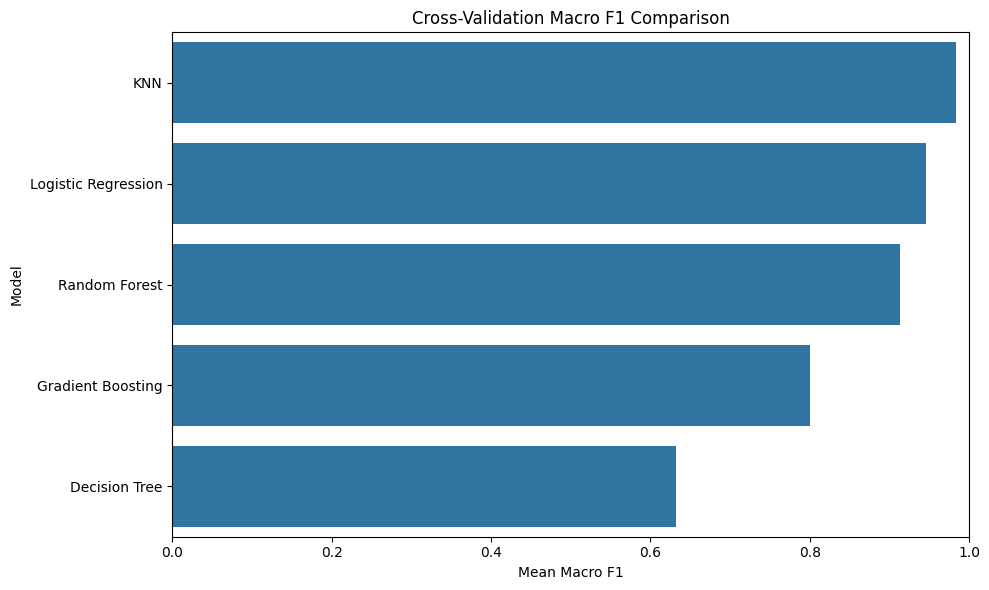

In [24]:
# --------------------------------------------------
# Macro F1 Comparison
# --------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_results_df,
    x="F1 Mean",
    y="Model"
)

plt.title("Cross-Validation Macro F1 Comparison")
plt.xlabel("Mean Macro F1")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()

plt.show()

In [25]:
# --------------------------------------------------
# Cross-Validation Metric Comparison
# --------------------------------------------------

metric_columns = [
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean"
]

metric_comparison = cv_results_df[
    ["Model"] + metric_columns
].copy()

metric_comparison = metric_comparison.set_index("Model")

print("=" * 60)
print("CROSS-VALIDATION METRIC COMPARISON")
print("=" * 60)

display(
    metric_comparison.round(4)
)

CROSS-VALIDATION METRIC COMPARISON


,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean
Model,,,,
KNN,0.9632,0.9826,0.9896,0.9840
Logistic Regression,0.8899,0.9434,0.9699,0.9462
Random Forest,0.8423,0.9086,0.9446,0.9133
Gradient Boosting,0.6727,0.7952,0.8625,0.8000
Decision Tree,0.5153,0.6345,0.6995,0.6324


In [26]:
# --------------------------------------------------
# Cross-Validation Variability
# --------------------------------------------------

variability_table = cv_results_df[
    [
        "Model",
        "Accuracy Std",
        "Precision Std",
        "Recall Std",
        "F1 Std"
    ]
].copy()

print("=" * 60)
print("CROSS-VALIDATION VARIABILITY")
print("=" * 60)

display(
    variability_table.round(4)
)

CROSS-VALIDATION VARIABILITY


,Model,Accuracy Std,Precision Std,Recall Std,F1 Std
0,KNN,0.0450,0.0215,0.0127,0.0199
1,Logistic Regression,0.0685,0.0348,0.0184,0.0332
2,Random Forest,0.1182,0.0700,0.0438,0.0679
3,Gradient Boosting,0.0732,0.0425,0.0291,0.0429
4,Decision Tree,0.0994,0.0338,0.0194,0.0292


# 17. Select Model Based on Cross-Validation

The candidate model with the highest mean Macro F1-score across the
five cross-validation folds is selected for final training.

Model selection is performed exclusively using cross-validation
results.

The held-out test set remains untouched until the final evaluation.

In [27]:
# --------------------------------------------------
# Select Best Model
# --------------------------------------------------

best_model_name = cv_results_df.iloc[0]["Model"]
best_cv_f1 = cv_results_df.iloc[0]["F1 Mean"]

print("=" * 60)
print("MODEL SELECTION")
print("=" * 60)

print(f"Selected model : {best_model_name}")
print(f"CV Macro F1    : {best_cv_f1:.4f}")

print("\n✓ Model selected using cross-validation Macro F1.")

MODEL SELECTION
Selected model : KNN
CV Macro F1    : 0.9840

✓ Model selected using cross-validation Macro F1.


In [28]:
# --------------------------------------------------
# Retrieve Selected Pipeline
# --------------------------------------------------

best_pipeline = pipelines[best_model_name]

print("=" * 60)
print("SELECTED PIPELINE")
print("=" * 60)

for step_name, step in best_pipeline.steps:
    print(f"{step_name:15} → {type(step).__name__}")

print("\n✓ Selected pipeline retrieved successfully.")

SELECTED PIPELINE
smote           → SMOTENC
preprocessor    → ColumnTransformer
model           → KNeighborsClassifier

✓ Selected pipeline retrieved successfully.


# 18. Train the Final Selected Model

The model selected through cross-validation is now trained using the
complete training dataset.

The complete training set is used so that the selected model can learn
from all available training records before the final evaluation.

The held-out test set remains completely untouched during this stage.

The pipeline contains:

1. SMOTENC
2. Feature preprocessing
3. Selected machine learning classifier

In [29]:
# --------------------------------------------------
# Train Final Selected Model
# --------------------------------------------------

print("=" * 60)
print("TRAINING FINAL SELECTED MODEL")
print("=" * 60)

print(f"Selected model : {best_model_name}")
print(f"Training rows  : {len(X_train_smote)}")
print(f"Training groups: {groups_train.nunique()}")

best_pipeline.fit(
    X_train_smote,
    y_train
)

print("\n✓ Final selected model trained successfully.")

TRAINING FINAL SELECTED MODEL
Selected model : KNN
Training rows  : 3924
Training groups: 245

✓ Final selected model trained successfully.


# 19. Final Test Evaluation

The selected model is evaluated on the held-out test set for the first
and only time.

The test set was not used during model selection or final model training.

The following metrics are reported:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

Macro F1-score remains the primary metric because the classification
problem contains multiple disease classes.

In [30]:
# --------------------------------------------------
# Final Test Prediction
# --------------------------------------------------

y_pred = best_pipeline.predict(X_test_smote)

print("=" * 60)
print("FINAL TEST PREDICTION")
print("=" * 60)

print(f"Test samples : {len(X_test_smote)}")
print(f"Predictions   : {len(y_pred)}")

print("\n✓ Final predictions generated successfully.")

FINAL TEST PREDICTION
Test samples : 996
Predictions   : 996

✓ Final predictions generated successfully.


In [31]:
# --------------------------------------------------
# Final Test Metrics
# --------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Selected Model : {best_model_name}")
print(f"Accuracy       : {final_accuracy:.4f}")
print(f"Macro Precision: {final_precision:.4f}")
print(f"Macro Recall   : {final_recall:.4f}")
print(f"Macro F1       : {final_f1:.4f}")

print("\n✓ Final test evaluation completed successfully.")

FINAL TEST RESULTS
Selected Model : KNN
Accuracy       : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000

✓ Final test evaluation completed successfully.


In [32]:
# --------------------------------------------------
# Compare CV and Final Test Performance
# --------------------------------------------------

performance_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Cross-Validation": [
        cv_results_df.loc[
            cv_results_df["Model"] == best_model_name,
            "Accuracy Mean"
        ].iloc[0],

        cv_results_df.loc[
            cv_results_df["Model"] == best_model_name,
            "Precision Mean"
        ].iloc[0],

        cv_results_df.loc[
            cv_results_df["Model"] == best_model_name,
            "Recall Mean"
        ].iloc[0],

        best_cv_f1
    ],
    "Final Test": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print("=" * 60)
print("CROSS-VALIDATION VS FINAL TEST")
print("=" * 60)

display(
    performance_summary.round(4)
)

CROSS-VALIDATION VS FINAL TEST


,Metric,Cross-Validation,Final Test
0,Accuracy,0.9632,1.0
1,Macro Precision,0.9826,1.0
2,Macro Recall,0.9896,1.0
3,Macro F1,0.9840,1.0


# 20. Classification Report and Per-Disease Performance

The final model's predictions on the held-out test set are analyzed
using a classification report.

Performance is reported separately for each disease class using:

- Precision
- Recall
- F1-score
- Support

This analysis helps identify disease classes where the model performs
strongly or where prediction performance is comparatively weaker.

In [33]:
# --------------------------------------------------
# Classification Report
# --------------------------------------------------

classification_report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

display(
    classification_report_df.round(4)
)

CLASSIFICATION REPORT


,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.0,12.0
AIDS,1.0,1.0,1.0,12.0
Acne,1.0,1.0,1.0,6.0
Alcoholic hepatitis,1.0,1.0,1.0,78.0
Allergy,1.0,1.0,1.0,12.0
Arthritis,1.0,1.0,1.0,6.0
Bronchial Asthma,1.0,1.0,1.0,12.0
Cervical spondylosis,1.0,1.0,1.0,6.0
Chicken pox,1.0,1.0,1.0,12.0
Chronic cholestasis,1.0,1.0,1.0,6.0


In [34]:
# --------------------------------------------------
# Disease-Level Performance
# --------------------------------------------------

disease_performance = classification_report_df.iloc[
    :len(y_test.unique())
].copy()

disease_performance = disease_performance[
    ["precision", "recall", "f1-score", "support"]
]

disease_performance = disease_performance.sort_values(
    by="f1-score",
    ascending=False
)

print("=" * 60)
print("DISEASE-LEVEL PERFORMANCE")
print("=" * 60)

display(
    disease_performance.round(4)
)

DISEASE-LEVEL PERFORMANCE


,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.0,12.0
AIDS,1.0,1.0,1.0,12.0
Acne,1.0,1.0,1.0,6.0
Alcoholic hepatitis,1.0,1.0,1.0,78.0
Allergy,1.0,1.0,1.0,12.0
Arthritis,1.0,1.0,1.0,6.0
Bronchial Asthma,1.0,1.0,1.0,12.0
Cervical spondylosis,1.0,1.0,1.0,6.0
Chicken pox,1.0,1.0,1.0,12.0
Chronic cholestasis,1.0,1.0,1.0,6.0


In [35]:
# --------------------------------------------------
# Lowest F1-Score Disease Classes
# --------------------------------------------------

weakest_diseases = disease_performance.sort_values(
    by="f1-score",
    ascending=True
).head(10)

print("=" * 60)
print("10 DISEASE CLASSES WITH LOWEST F1-SCORE")
print("=" * 60)

display(
    weakest_diseases.round(4)
)

10 DISEASE CLASSES WITH LOWEST F1-SCORE


,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.0,12.0
AIDS,1.0,1.0,1.0,12.0
Acne,1.0,1.0,1.0,6.0
Alcoholic hepatitis,1.0,1.0,1.0,78.0
Allergy,1.0,1.0,1.0,12.0
Arthritis,1.0,1.0,1.0,6.0
Bronchial Asthma,1.0,1.0,1.0,12.0
Cervical spondylosis,1.0,1.0,1.0,6.0
Chicken pox,1.0,1.0,1.0,12.0
Chronic cholestasis,1.0,1.0,1.0,6.0


In [36]:
# --------------------------------------------------
# Highest F1-Score Disease Classes
# --------------------------------------------------

strongest_diseases = disease_performance.sort_values(
    by="f1-score",
    ascending=False
).head(10)

print("=" * 60)
print("10 DISEASE CLASSES WITH HIGHEST F1-SCORE")
print("=" * 60)

display(
    strongest_diseases.round(4)
)

10 DISEASE CLASSES WITH HIGHEST F1-SCORE


,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.0,1.0,1.0,12.0
AIDS,1.0,1.0,1.0,12.0
Acne,1.0,1.0,1.0,6.0
Alcoholic hepatitis,1.0,1.0,1.0,78.0
Allergy,1.0,1.0,1.0,12.0
Arthritis,1.0,1.0,1.0,6.0
Bronchial Asthma,1.0,1.0,1.0,12.0
Cervical spondylosis,1.0,1.0,1.0,6.0
Chicken pox,1.0,1.0,1.0,12.0
Chronic cholestasis,1.0,1.0,1.0,6.0


# 21. Confusion Matrix Analysis

A confusion matrix is used to analyze the final model's predictions
across the disease classes.

Rows represent the actual disease classes, while columns represent
the predicted disease classes.

The diagonal represents correct predictions.

Off-diagonal values represent cases where the model predicted a
different disease class.

In [37]:
# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(f"Matrix shape: {cm.shape}")
print(f"Number of classes: {len(labels)}")

CONFUSION MATRIX
Matrix shape: (41, 41)
Number of classes: 41


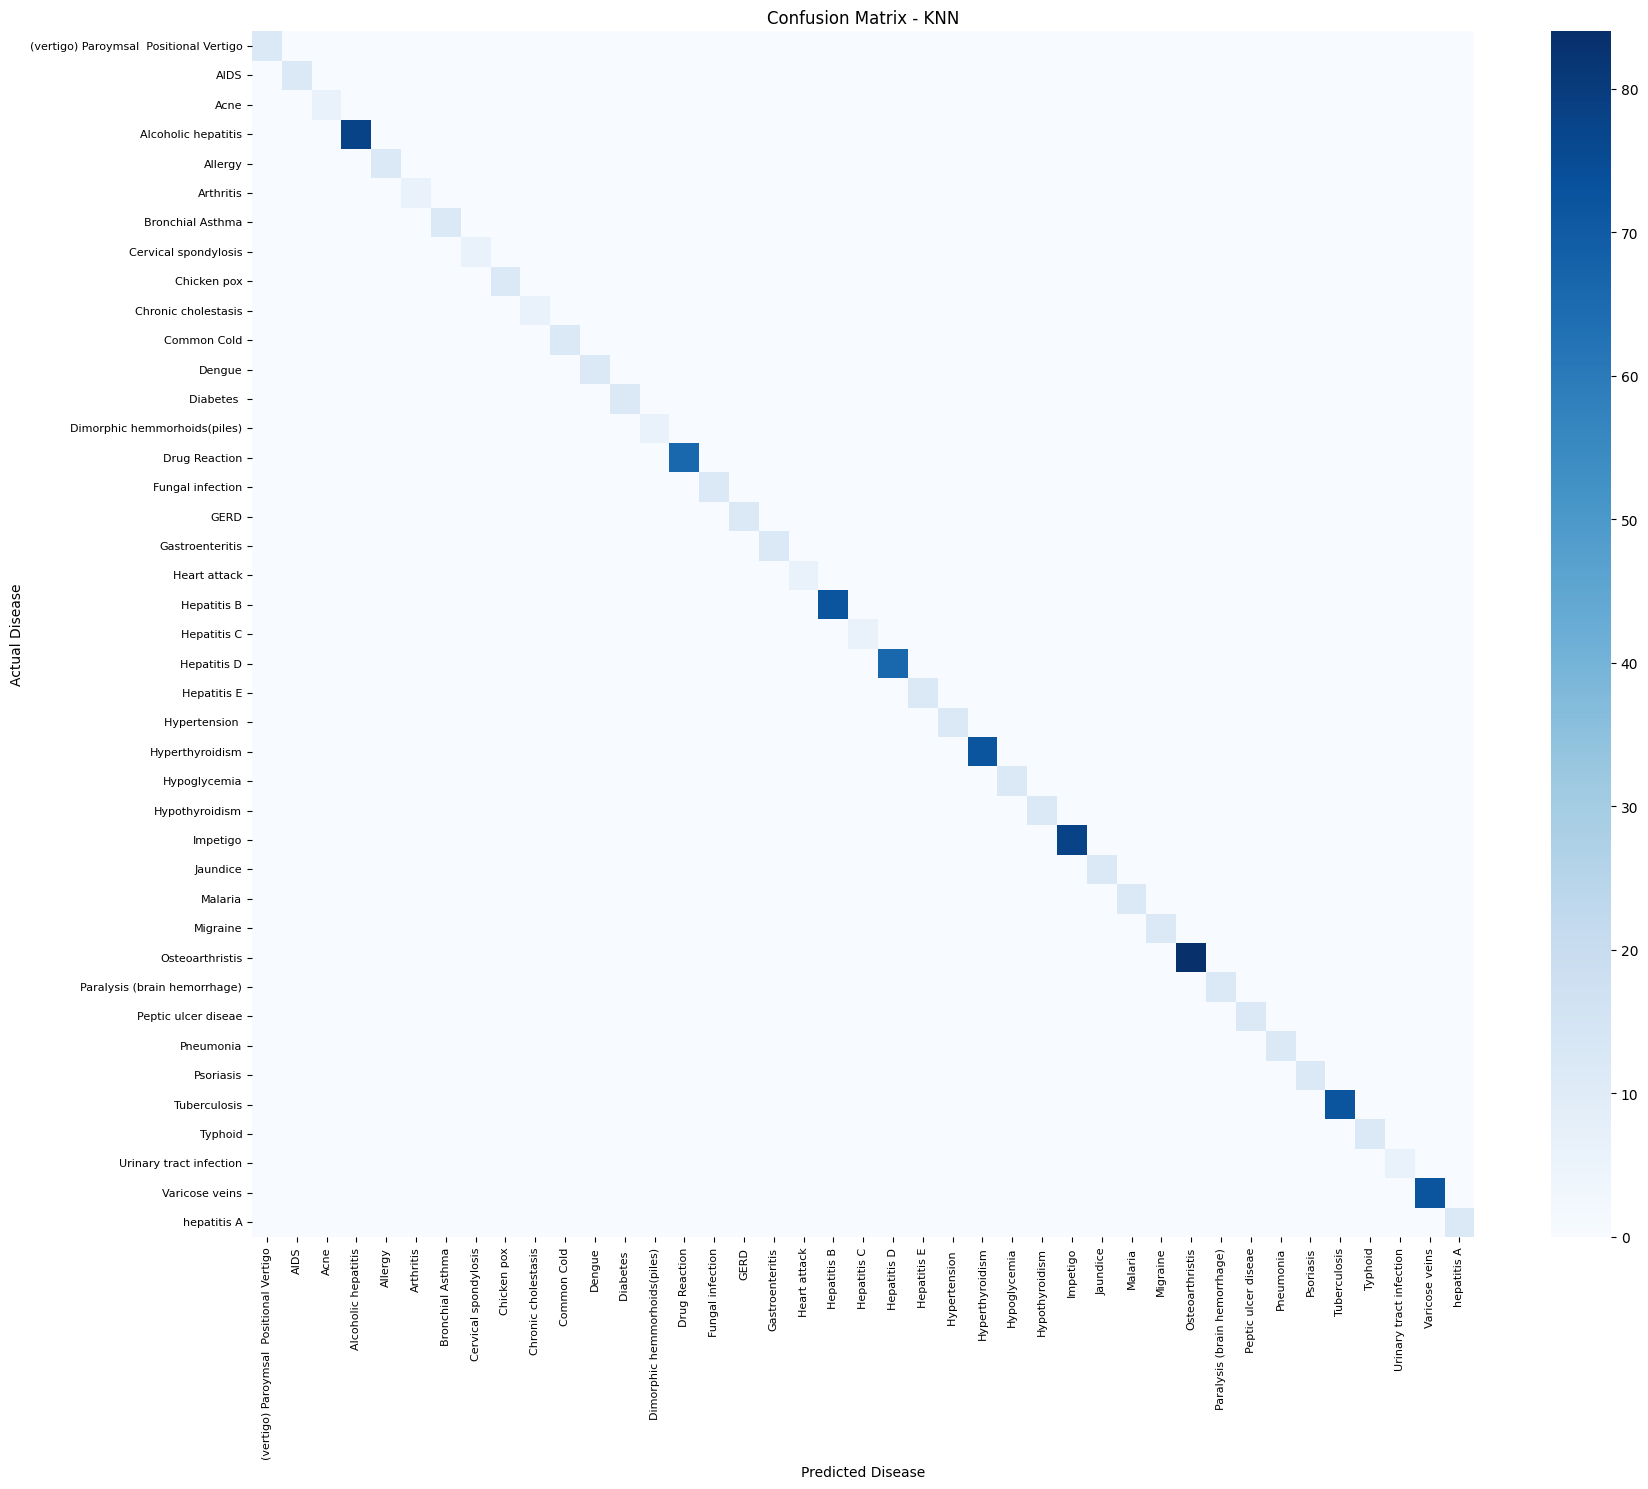

In [38]:
# --------------------------------------------------
# Confusion Matrix Heatmap
# --------------------------------------------------

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()

plt.show()

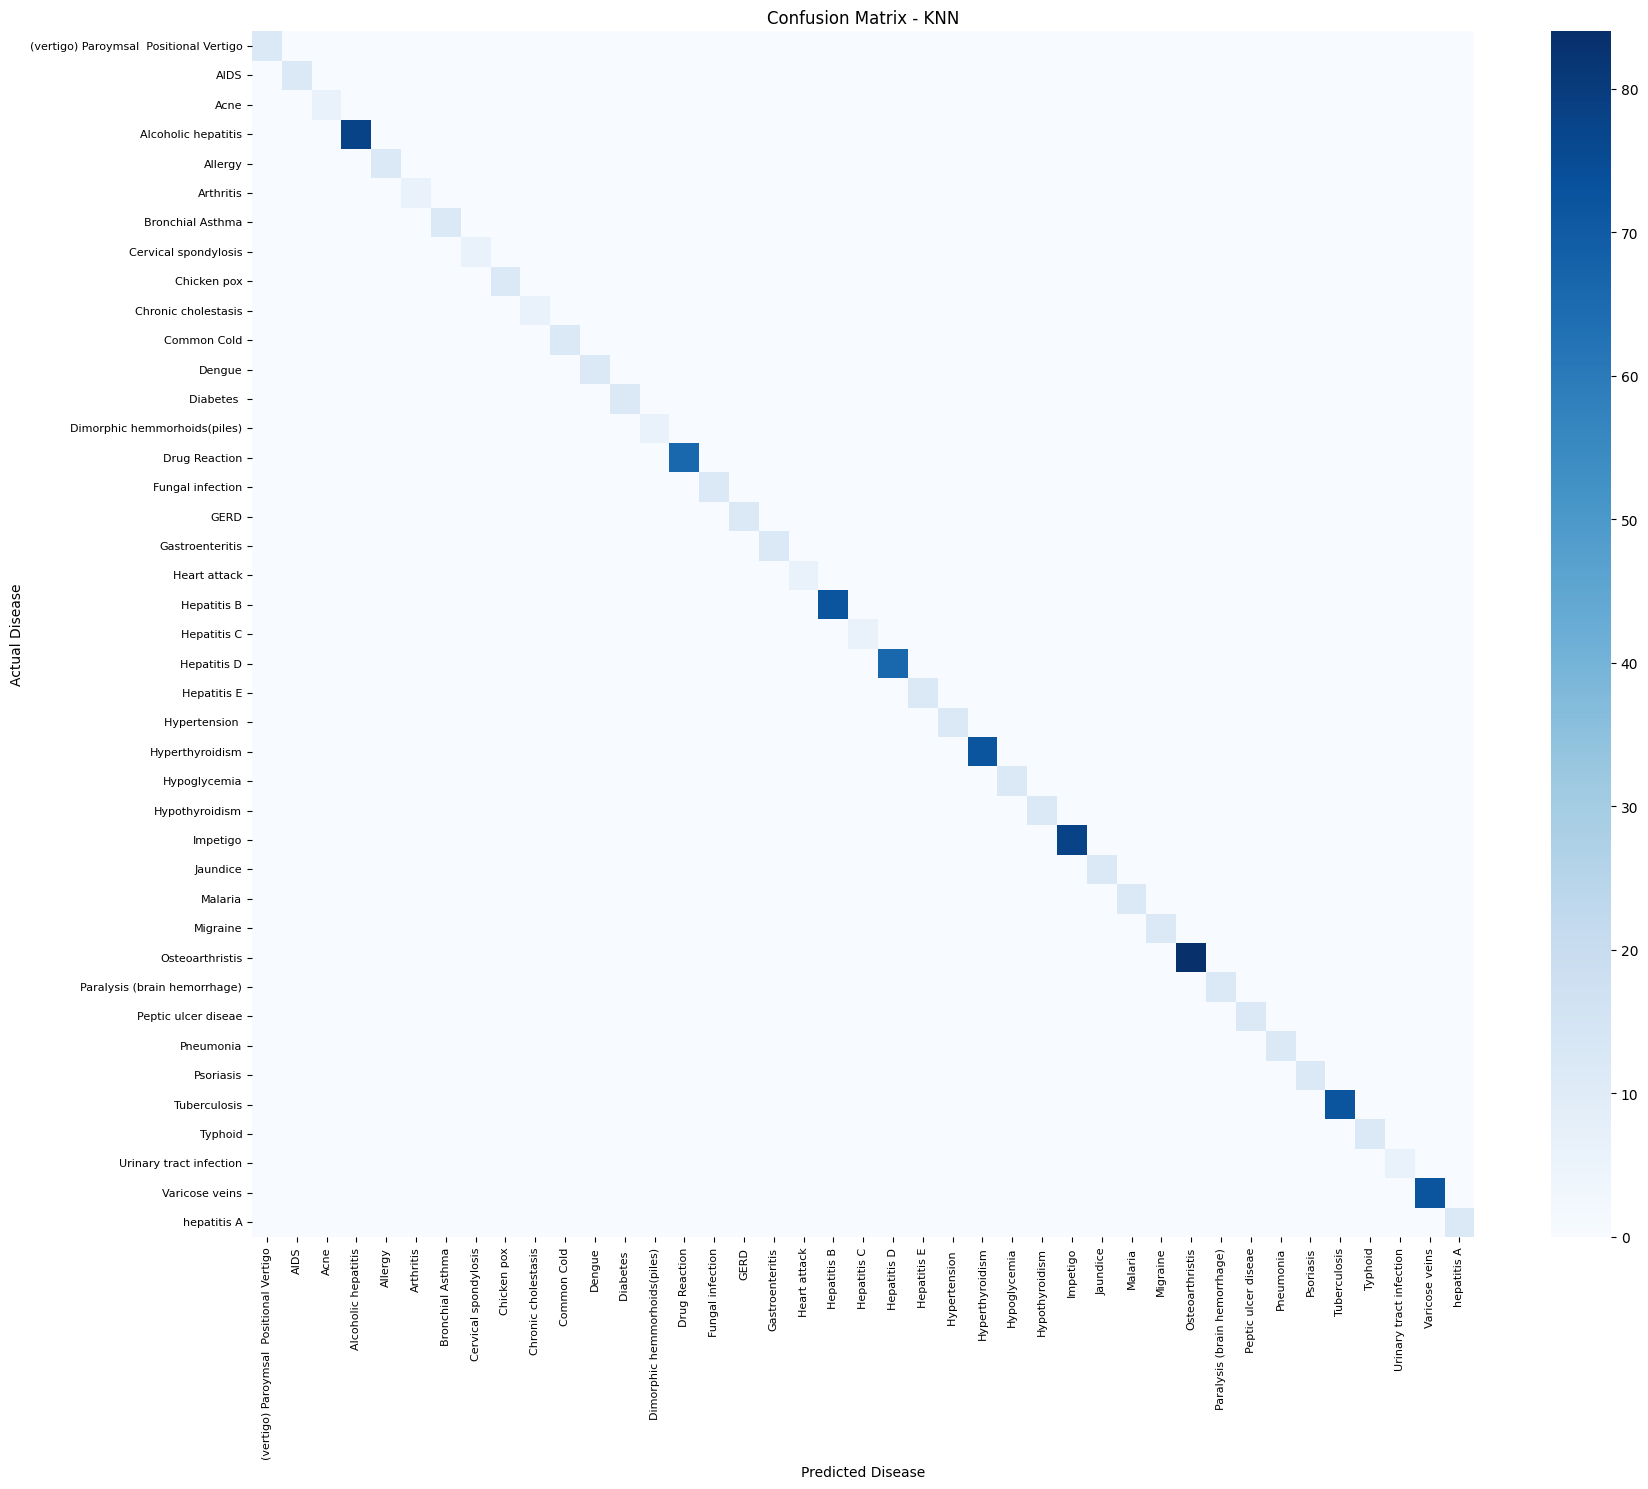

✓ Confusion matrix saved to:
E:\AI_Disease_Prediction\data\processed\model_results\confusion_matrix.png


In [39]:
# --------------------------------------------------
# Save Confusion Matrix Figure
# --------------------------------------------------

CONFUSION_MATRIX_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_results"
)

CONFUSION_MATRIX_DIR.mkdir(
    parents=True,
    exist_ok=True
)

confusion_matrix_path = (
    CONFUSION_MATRIX_DIR
    / "confusion_matrix.png"
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Confusion matrix saved to:")
print(confusion_matrix_path.resolve())

# 22. Save Model Results and Evaluation Metrics

The results generated during model development are saved as CSV files.

The following outputs are stored:

- Cross-validation results for all candidate models
- Final model performance summary
- Disease-level classification performance
- Complete classification report
- Confusion matrix
- Actual vs predicted test-set results

These files provide reproducible records of the model evaluation process
and can later be used for reporting, visualization, and documentation.

In [40]:
MODEL_RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_results"
)

MODEL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# 1. Cross-validation results
cv_results_path = MODEL_RESULTS_DIR / "cross_validation_results.csv"
cv_results_df.to_csv(
    cv_results_path,
    index=False
)

# 2. Final performance summary
performance_summary_path = (
    MODEL_RESULTS_DIR
    / "final_performance_summary.csv"
)

performance_summary.to_csv(
    performance_summary_path,
    index=False
)

# 3. Complete classification report
classification_report_path = (
    MODEL_RESULTS_DIR
    / "classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path,
    index=True
)

# 4. Disease-level performance
disease_performance_path = (
    MODEL_RESULTS_DIR
    / "disease_level_performance.csv"
)

disease_performance.to_csv(
    disease_performance_path,
    index=True
)

# 5. Confusion matrix
confusion_matrix_csv_path = (
    MODEL_RESULTS_DIR
    / "confusion_matrix.csv"
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

confusion_matrix_df.to_csv(
    confusion_matrix_csv_path
)

# 6. Actual vs predicted results
predictions_df = pd.DataFrame({
    "Actual_Disease": y_test.values,
    "Predicted_Disease": y_pred
})

predictions_path = (
    MODEL_RESULTS_DIR
    / "test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

print("=" * 60)
print("MODEL RESULTS SAVED")
print("=" * 60)

print(f"✓ Cross-validation results:")
print(f"  {cv_results_path.resolve()}")

print(f"\n✓ Final performance summary:")
print(f"  {performance_summary_path.resolve()}")

print(f"\n✓ Classification report:")
print(f"  {classification_report_path.resolve()}")

print(f"\n✓ Disease-level performance:")
print(f"  {disease_performance_path.resolve()}")

print(f"\n✓ Confusion matrix:")
print(f"  {confusion_matrix_csv_path.resolve()}")

print(f"\n✓ Test predictions:")
print(f"  {predictions_path.resolve()}")

print("\n✓ All model evaluation results saved successfully.")

MODEL RESULTS SAVED
✓ Cross-validation results:
  E:\AI_Disease_Prediction\data\processed\model_results\cross_validation_results.csv

✓ Final performance summary:
  E:\AI_Disease_Prediction\data\processed\model_results\final_performance_summary.csv

✓ Classification report:
  E:\AI_Disease_Prediction\data\processed\model_results\classification_report.csv

✓ Disease-level performance:
  E:\AI_Disease_Prediction\data\processed\model_results\disease_level_performance.csv

✓ Confusion matrix:
  E:\AI_Disease_Prediction\data\processed\model_results\confusion_matrix.csv

✓ Test predictions:
  E:\AI_Disease_Prediction\data\processed\model_results\test_predictions.csv

✓ All model evaluation results saved successfully.


# 23. Save the Final Trained Model

The final selected machine learning pipeline is saved to the project's
`models` directory.

The complete pipeline is saved rather than only the classifier because
the pipeline contains:

1. SMOTENC
2. Feature preprocessing
3. One-Hot Encoding
4. Standard Scaling
5. The selected machine learning model

Saving the complete pipeline allows the same preprocessing and model
configuration to be reused during deployment.

In [41]:
FINAL_MODEL_PATH = (
    MODEL_DIR
    / "disease_prediction_model.pkl"
)

dump(
    best_pipeline,
    FINAL_MODEL_PATH
)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

print(f"Selected model : {best_model_name}")
print(f"Model path     : {FINAL_MODEL_PATH.resolve()}")

print("\n✓ Final trained pipeline saved successfully.")

FINAL MODEL SAVED
Selected model : KNN
Model path     : E:\AI_Disease_Prediction\models\disease_prediction_model.pkl

✓ Final trained pipeline saved successfully.


# 24. Verify the Saved Model

The saved machine learning pipeline is loaded from disk and tested
against the held-out test dataset.

This verification ensures that:

- The saved file can be loaded successfully.
- The complete preprocessing pipeline is preserved.
- The loaded model can generate predictions.
- The loaded model produces the same predictions as the original
  trained pipeline.

In [42]:
from joblib import load

loaded_model = load(
    FINAL_MODEL_PATH
)

loaded_predictions = loaded_model.predict(
    X_test_smote
)

predictions_match = np.array_equal(
    y_pred,
    loaded_predictions
)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

loaded_f1 = f1_score(
    y_test,
    loaded_predictions,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("SAVED MODEL VERIFICATION")
print("=" * 60)

print(f"Loaded model type : {type(loaded_model).__name__}")
print(f"Predictions match : {predictions_match}")
print(f"Loaded accuracy   : {loaded_accuracy:.4f}")
print(f"Loaded Macro F1   : {loaded_f1:.4f}")

assert predictions_match, \
    "Loaded model predictions do not match the original predictions."

assert np.isclose(
    loaded_accuracy,
    final_accuracy
), "Loaded model accuracy does not match the original result."

assert np.isclose(
    loaded_f1,
    final_f1
), "Loaded model Macro F1 does not match the original result."

print("\n✓ Saved model verification passed successfully.")

SAVED MODEL VERIFICATION
Loaded model type : Pipeline
Predictions match : True
Loaded accuracy   : 1.0000
Loaded Macro F1   : 1.0000

✓ Saved model verification passed successfully.


# 25. Create Final Experiment Summary

A final experiment summary is created to document the configuration
and performance of the completed model-training experiment.

The summary records:

- Dataset size
- Number of disease classes
- Number of features
- Training and test sizes
- Cross-validation strategy
- Number of folds
- Primary evaluation metric
- Selected model
- Cross-validation Macro F1
- Final test performance
- Model file location

In [43]:
experiment_summary = pd.DataFrame({
    "Property": [
        "Dataset rows",
        "Feature count",
        "Disease classes",
        "Training samples",
        "Test samples",
        "Cross-validation",
        "CV folds",
        "Primary metric",
        "Selected model",
        "CV Macro F1",
        "Test Accuracy",
        "Test Macro Precision",
        "Test Macro Recall",
        "Test Macro F1",
        "Model file"
    ],
    "Value": [
        len(df),
        X.shape[1],
        y.nunique(),
        len(X_train),
        len(X_test),
        "StratifiedGroupKFold",
        5,
        "Macro F1",
        best_model_name,
        round(best_cv_f1, 4),
        round(final_accuracy, 4),
        round(final_precision, 4),
        round(final_recall, 4),
        round(final_f1, 4),
        str(FINAL_MODEL_PATH)
    ]
})

print("=" * 60)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 60)

display(experiment_summary)

experiment_summary_path = (
    MODEL_RESULTS_DIR
    / "experiment_summary.csv"
)

experiment_summary.to_csv(
    experiment_summary_path,
    index=False
)

print("\n✓ Experiment summary saved successfully.")

FINAL EXPERIMENT SUMMARY


,Property,Value
0,Dataset rows,4920
1,Feature count,18
2,Disease classes,41
3,Training samples,3924
4,Test samples,996
5,Cross-validation,StratifiedGroupKFold
6,CV folds,5
7,Primary metric,Macro F1
8,Selected model,KNN
9,CV Macro F1,0.984



✓ Experiment summary saved successfully.


# 26. Final Model Performance Visualization

The final cross-validation and held-out test performance of the
selected model are visualized for the main evaluation metrics.

This visualization provides a concise overview of the model's
generalization performance.

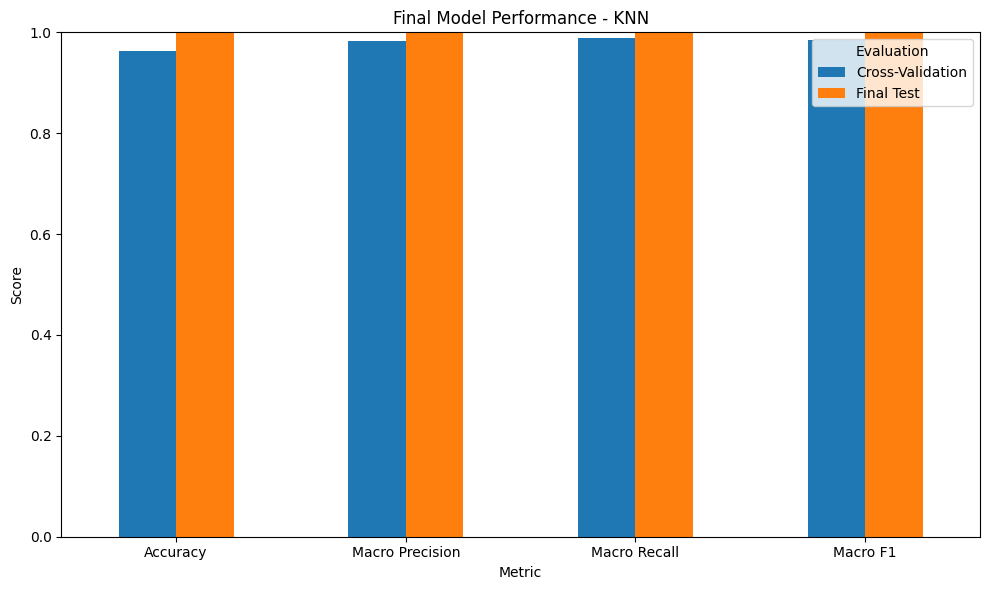

In [44]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Cross-Validation": [
        performance_summary.loc[
            performance_summary["Metric"] == "Accuracy",
            "Cross-Validation"
        ].iloc[0],
        performance_summary.loc[
            performance_summary["Metric"] == "Macro Precision",
            "Cross-Validation"
        ].iloc[0],
        performance_summary.loc[
            performance_summary["Metric"] == "Macro Recall",
            "Cross-Validation"
        ].iloc[0],
        performance_summary.loc[
            performance_summary["Metric"] == "Macro F1",
            "Cross-Validation"
        ].iloc[0]
    ],
    "Final Test": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_metrics_plot = final_metrics.set_index("Metric")

ax = final_metrics_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    f"Final Model Performance - {best_model_name}"
)

ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Evaluation")
plt.tight_layout()
plt.show()

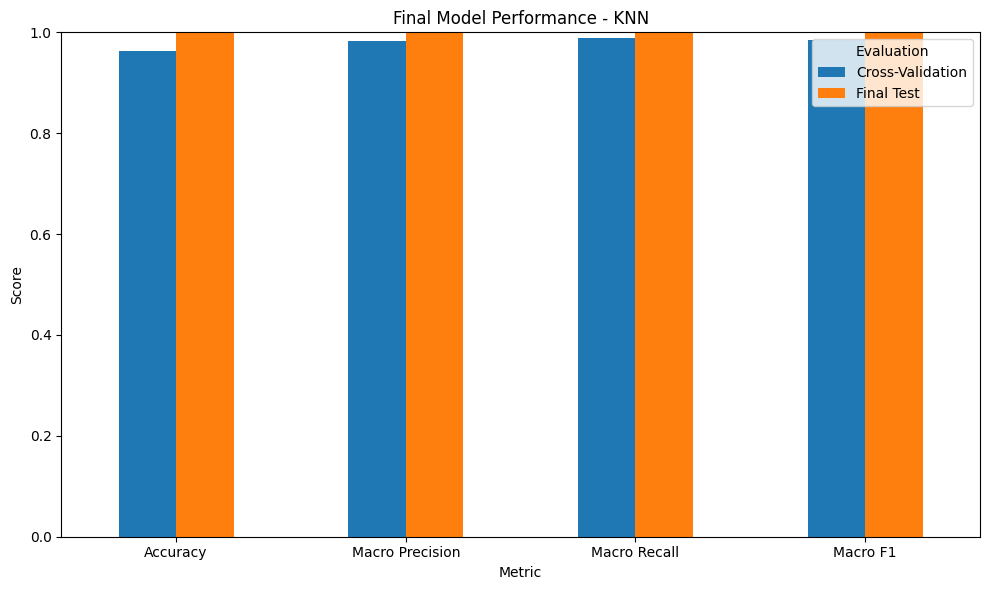

✓ Final performance plot saved to:
E:\AI_Disease_Prediction\data\processed\model_results\final_model_performance.png


In [45]:
final_performance_plot_path = (
    MODEL_RESULTS_DIR
    / "final_model_performance.png"
)

fig = final_metrics_plot.plot(
    kind="bar",
    figsize=(10, 6)
).get_figure()

plt.title(
    f"Final Model Performance - {best_model_name}"
)

plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Evaluation")
plt.tight_layout()

fig.savefig(
    final_performance_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Final performance plot saved to:\n"
    f"{final_performance_plot_path.resolve()}"
)

# 27. Model Training Summary

The model-development workflow has been completed using a leakage-aware
and reproducible training procedure.

## Data Preparation

- Processed dataset generated from the data-cleaning stage
- Symptom features treated as categorical variables
- `Symptom_Count` treated as a numerical feature
- Complete symptom patterns used as groups

## Data Splitting

- Stratified group-aware train/test split
- Five-fold `StratifiedGroupKFold` cross-validation
- No symptom-pattern group overlap between training and test sets

## Class Imbalance Handling

- `SMOTENC` used for categorical symptom features
- SMOTENC placed inside the machine learning pipeline
- Oversampling therefore occurs only within training folds

## Candidate Models

The following models were compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. K-Nearest Neighbors

## Model Selection

The final model was selected using the highest mean Macro F1-score
from cross-validation.

The held-out test set was reserved for final evaluation.

## Final Evaluation

The selected model was evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Per-disease classification metrics
- Confusion matrix

## Model Persistence

The complete trained pipeline was saved using Joblib so that the same
preprocessing and prediction workflow can be reused during deployment.

# 28. Final Notebook Validation

The final validation checks whether the complete model-training
workflow produced the expected artifacts.

The checks include:

- Processed dataset availability
- Model results directory
- Saved model
- Cross-validation results
- Classification report
- Confusion matrix
- Test predictions
- Experiment summary

All major outputs should exist before this notebook is considered
complete.

In [46]:
required_outputs = {
    "Processed dataset": DATA_FILE,
    "Saved model": FINAL_MODEL_PATH,
    "Cross-validation results": cv_results_path,
    "Final performance summary": performance_summary_path,
    "Classification report": classification_report_path,
    "Disease-level performance": disease_performance_path,
    "Confusion matrix CSV": confusion_matrix_csv_path,
    "Confusion matrix image": confusion_matrix_path,
    "Test predictions": predictions_path,
    "Experiment summary": experiment_summary_path,
    "Final performance plot": final_performance_plot_path
}

print("=" * 60)
print("FINAL NOTEBOOK VALIDATION")
print("=" * 60)

validation_results = []

for output_name, output_path in required_outputs.items():

    exists = output_path.exists()

    validation_results.append({
        "Output": output_name,
        "Exists": exists,
        "Path": str(output_path)
    })

    status = "✓" if exists else "✗"

    print(f"{status} {output_name}")

validation_df = pd.DataFrame(validation_results)

print("\n")
display(validation_df)

assert all(
    validation_df["Exists"]
), "One or more required outputs are missing."

print("\n✓ All required model-training outputs are available.")
print("✓ MODEL TRAINING NOTEBOOK COMPLETED SUCCESSFULLY.")

FINAL NOTEBOOK VALIDATION
✓ Processed dataset
✓ Saved model
✓ Cross-validation results
✓ Final performance summary
✓ Classification report
✓ Disease-level performance
✓ Confusion matrix CSV
✓ Confusion matrix image
✓ Test predictions
✓ Experiment summary
✓ Final performance plot




,Output,Exists,Path
0,Processed dataset,True,..\data\processed\disease_clean.csv
1,Saved model,True,..\models\disease_prediction_model.pkl
2,Cross-validation results,True,..\data\processed\model_results\cross_validati...
3,Final performance summary,True,..\data\processed\model_results\final_performa...
4,Classification report,True,..\data\processed\model_results\classification...
5,Disease-level performance,True,..\data\processed\model_results\disease_level_...
6,Confusion matrix CSV,True,..\data\processed\model_results\confusion_matr...
7,Confusion matrix image,True,..\data\processed\model_results\confusion_matr...
8,Test predictions,True,..\data\processed\model_results\test_predictio...
9,Experiment summary,True,..\data\processed\model_results\experiment_sum...



✓ All required model-training outputs are available.
✓ MODEL TRAINING NOTEBOOK COMPLETED SUCCESSFULLY.


# 29. Conclusion

The machine learning development stage of the AI Disease Prediction
System has been completed.

The processed disease-symptom dataset was prepared for classification,
and multiple machine learning algorithms were evaluated using
Stratified Group K-Fold cross-validation.

SMOTENC was integrated into the training pipeline to address class
imbalance while preserving the categorical nature of the symptom
features.

The final model was selected using cross-validation Macro F1-score and
was subsequently evaluated on the held-out test set.

The complete trained pipeline, evaluation metrics, classification
results, confusion matrix, and prediction outputs have been saved for
use in the next stages of the project.

## Next Stage

The next notebook will focus on **model interpretability using SHAP**.

The SHAP analysis will help explain how symptom features contribute to
the model's predictions and will provide interpretable information
for the AI disease prediction system.